In [24]:
!pip install stats_can

In [25]:
# ==========================================
# 1. LIBRARIES & SETUP
# ==========================================
import io
import zipfile
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Global visualization style setup
sns.set_theme(style="whitegrid", context="talk")

In [26]:


# 1. Download official StatCan ZIP file (Table 14-10-0083-01)
url = "https://www150.statcan.gc.ca/n1/tbl/csv/14100083-eng.zip"
print("Downloading data from Statistics Canada...")
response = requests.get(url)

with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    df_raw = pd.read_csv(z.open("14100083.csv"))

print("Download completed!")

# 2. Filter data for Quebec
df_quebec = df_raw[
    (df_raw["GEO"] == "Quebec")
    & (df_raw["Labour force characteristics"] == "Unemployment rate")
    & (df_raw["Age group"] == "15 years and over")
].copy()

# 3. Clean and select columns
columns_of_interest = ["REF_DATE", "Immigrant status", "VALUE"]
df_clean = df_quebec[columns_of_interest].rename(
    columns={
        "REF_DATE": "Year",
        "Immigrant status": "Immigration_Status",
        "VALUE": "Unemployment_Rate_Pct",
    }
)
df_clean = df_clean.dropna(subset=["Unemployment_Rate_Pct"])

# Convert the year to integer
df_clean["Year"] = df_clean["Year"].astype(int)

print("\nPreview of clean data:")
display(df_clean.head(10))

Download completed!

Preview of clean data:


,Year,Immigration_Status,Unemployment_Rate_Pct
734,2006,Total population,8.3
754,2006,Landed immigrants,13.2
774,2006,"Immigrants, landed 5 or less years earlier",18.8
794,2006,"Immigrants, landed more than 5 to 10 years ear...",16.6
814,2006,"Immigrants, landed more than 10 years earlier",10.4
834,2006,Born in Canada,7.6
2654,2007,Total population,7.4
2674,2007,Landed immigrants,10.7
2694,2007,"Immigrants, landed 5 or less years earlier",15.7
2714,2007,"Immigrants, landed more than 5 to 10 years ear...",10.6


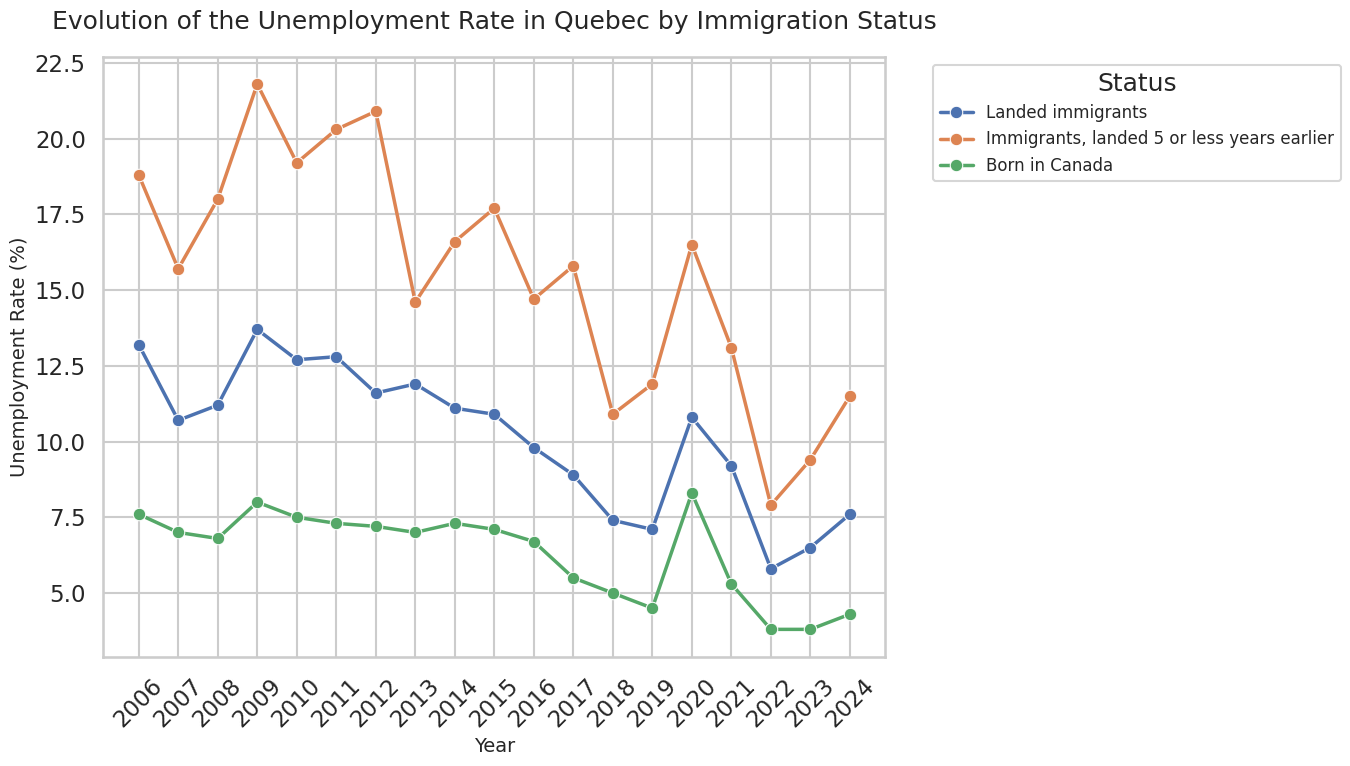

In [27]:


# Set plot style
sns.set_theme(style="whitegrid", context="talk")

# Exact category names from the dataset
key_categories = [
    'Born in Canada',
    'Landed immigrants',
    'Immigrants, landed 5 or less years earlier',
]

df_plot = df_clean[df_clean['Immigration_Status'].isin(key_categories)]

# Create time-series plot
fig, ax = plt.subplots(figsize=(14, 8))
sns.lineplot(
    data=df_plot,
    x='Year',
    y='Unemployment_Rate_Pct',
    hue='Immigration_Status',
    linewidth=2.5,
    marker='o',
    ax=ax,
)

# Force integer years on X-axis
years = sorted(df_plot['Year'].unique())
ax.set_xticks(years)
ax.set_xticklabels(years, rotation=45)

# Customization
plt.title(
    'Evolution of the Unemployment Rate in Quebec by Immigration Status',
    fontsize=18,
    pad=20,
)
plt.ylabel('Unemployment Rate (%)', fontsize=14)
plt.xlabel('Year', fontsize=14)
plt.legend(title='Status', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
plt.tight_layout()
plt.show()

In [28]:
# 1. Define comparable categories
categories_of_interest = [
    'Born in Canada',
    'Immigrants, landed more than 10 years earlier',
    'Immigrants, landed 5 or less years earlier',
]

# 2. Filter data for the years 2021, 2022, and 2023
df_unemployment = df_clean[
    (df_clean['Immigration_Status'].isin(categories_of_interest))
    & (df_clean['Year'].isin([2021, 2022, 2023]))
].copy()

# 3. Map to shorter English labels
short_names_en = {
    'Born in Canada': 'Canadian-born',
    'Immigrants, landed more than 10 years earlier': 'Immigrants (>10 years)',
    'Immigrants, landed 5 or less years earlier': 'Immigrants (≤5 years)',
}
df_unemployment['Status'] = df_unemployment['Immigration_Status'].map(short_names_en)

# 4. Select and sort desired columns
df_unemployment = df_unemployment[['Year', 'Status', 'Unemployment_Rate_Pct']].sort_values(
    by=['Year', 'Status']
)
df_unemployment.reset_index(drop=True, inplace=True)

# 5. Display preview
display(df_unemployment)

,Year,Status,Unemployment_Rate_Pct
0,2021,Canadian-born,5.3
1,2021,Immigrants (>10 years),8.1
2,2021,Immigrants (≤5 years),13.1
3,2022,Canadian-born,3.8
4,2022,Immigrants (>10 years),5.7
5,2022,Immigrants (≤5 years),7.9
6,2023,Canadian-born,3.8
7,2023,Immigrants (>10 years),5.5
8,2023,Immigrants (≤5 years),9.4


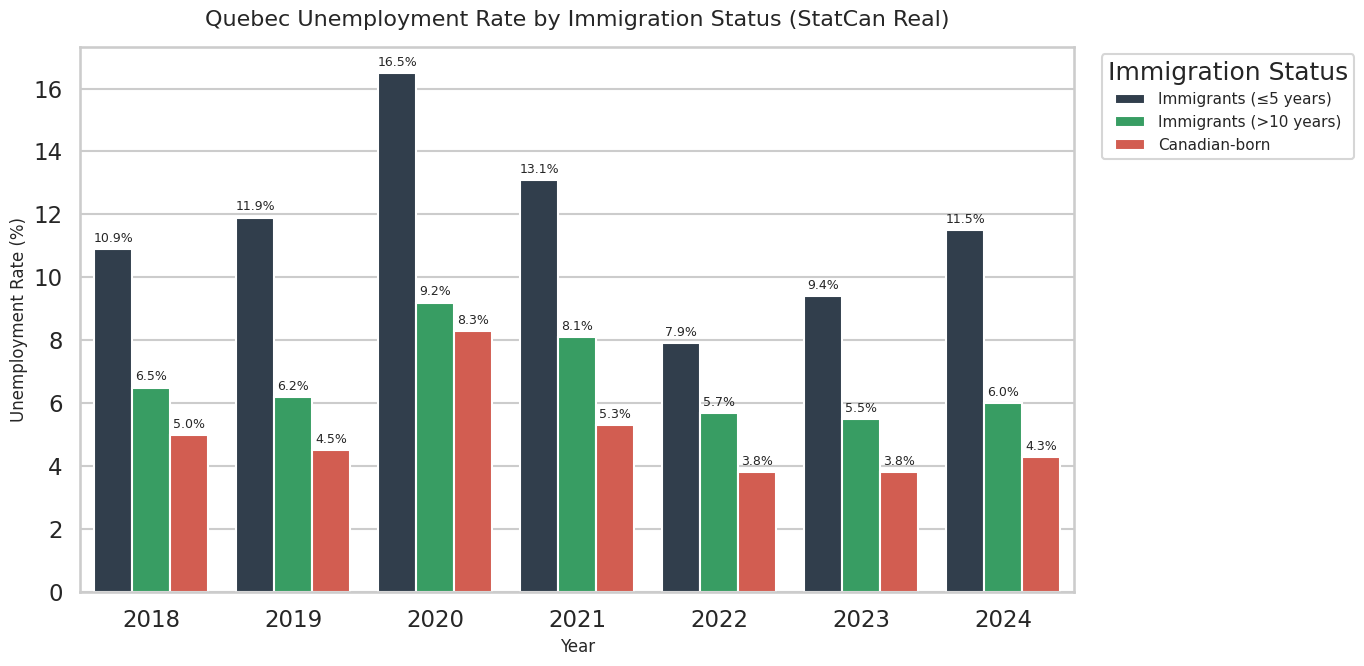

In [29]:
# 1. Filter the 3 comparable categories using the cleaned StatCan data
comparison_categories = [
    'Born in Canada',
    'Immigrants, landed more than 10 years earlier',
    'Immigrants, landed 5 or less years earlier',
]

df_bars = df_clean[
    df_clean['Immigration_Status'].isin(comparison_categories)
].copy()

# Map to shorter English labels for better readability on the chart
short_names_en = {
    'Born in Canada': 'Canadian-born',
    'Immigrants, landed more than 10 years earlier': 'Immigrants (>10 years)',
    'Immigrants, landed 5 or less years earlier': 'Immigrants (≤5 years)',
}
df_bars['Status'] = df_bars['Immigration_Status'].map(short_names_en)

# 2. Filter for recent years (e.g., 2018 onwards) for a clearer visualization
df_bars = df_bars[df_bars['Year'] >= 2018]

# 3. Create the bar chart
plt.figure(figsize=(14, 7))
ax = sns.barplot(
    data=df_bars,
    x='Year',
    y='Unemployment_Rate_Pct',
    hue='Status',
    palette=['#2c3e50', '#27ae60', '#e74c3c'],
)

# 4. Customize the chart
plt.title(
    'Quebec Unemployment Rate by Immigration Status (StatCan Real)',
    fontsize=16,
    pad=15,
)
plt.ylabel('Unemployment Rate (%)', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.legend(
    title='Immigration Status',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    fontsize=11,
)

# 5. Add percentage labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, size=9)

plt.tight_layout()
plt.show()

Download completed!


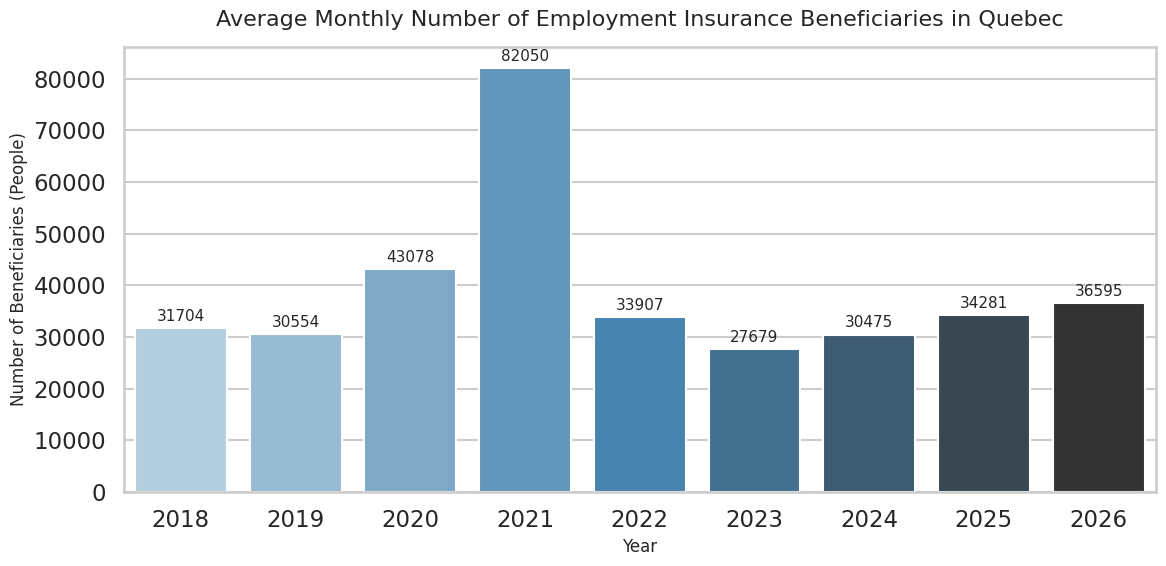

,Year,Avg_Monthly_Beneficiaries
21,2018,31704.0
22,2019,30554.0
23,2020,43078.0
24,2021,82050.0
25,2022,33907.0
26,2023,27679.0
27,2024,30475.0
28,2025,34281.0
29,2026,36595.0


In [30]:
# 1. Download official EI table (Table 14-10-0009-01)
url_ei = "https://www150.statcan.gc.ca/n1/tbl/csv/14100009-eng.zip"
print("Downloading Employment Insurance (EI) beneficiaries data...")
r_ei = requests.get(url_ei)

with zipfile.ZipFile(io.BytesIO(r_ei.content)) as z_ei:
    df_ei_raw = pd.read_csv(z_ei.open("14100009.csv"), low_memory=False)

print("Download completed!")

# 2. Dynamically locate the descriptive column for the benefit type
detail_col = [
    c for c in df_ei_raw.columns
    if any(k in c.lower() for k in ["characteristic", "detail", "benefit", "type"])
][0]

# 3. Filter for Quebec flexibly
df_ei_qc = df_ei_raw[
    df_ei_raw["GEO"].astype(str).str.startswith("Quebec")
    & df_ei_raw[detail_col].astype(str).str.contains("Total, all beneficiaries receiving regular benefits|Regular benefits", case=False, na=False)
    & df_ei_raw["Sex"].astype(str).str.contains("Both sexes|Both", case=False, na=False)
    & df_ei_raw["Age group"].astype(str).str.contains("Total", case=False, na=False)
].copy()

# Fallback if empty due to age/sex cross-filtering
if df_ei_qc.empty:
    df_ei_qc = df_ei_raw[
        df_ei_raw["GEO"].astype(str).str.startswith("Quebec")
        & df_ei_raw[detail_col].astype(str).str.contains("Regular benefits", case=False, na=False)
    ].copy()

# 4. Process dates and calculate annual average
df_ei_qc["Year"] = pd.to_datetime(df_ei_qc["REF_DATE"]).dt.year
df_ei_annual = (
    df_ei_qc.groupby("Year")["VALUE"]
    .mean()
    .reset_index()
    .rename(columns={"VALUE": "Avg_Monthly_Beneficiaries"})
)

# Filter recent years
df_ei_annual = df_ei_annual[df_ei_annual["Year"] >= 2018].copy()
df_ei_annual = df_ei_annual.dropna(subset=["Avg_Monthly_Beneficiaries"])
df_ei_annual["Avg_Monthly_Beneficiaries"] = df_ei_annual["Avg_Monthly_Beneficiaries"].round()

# 5. Generate plot
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=df_ei_annual,
    x="Year",
    y="Avg_Monthly_Beneficiaries",
    palette="Blues_d",
    hue="Year",       # Added to fix Seaborn deprecation warning
    legend=False      # Added to fix Seaborn deprecation warning
)

plt.title("Average Monthly Number of Employment Insurance Beneficiaries in Quebec", fontsize=16, pad=15)
plt.ylabel("Number of Beneficiaries (People)", fontsize=12)
plt.xlabel("Year", fontsize=12)

# Add numbers on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3, size=11)

plt.tight_layout()
plt.show()

display(df_ei_annual)

Download completed!


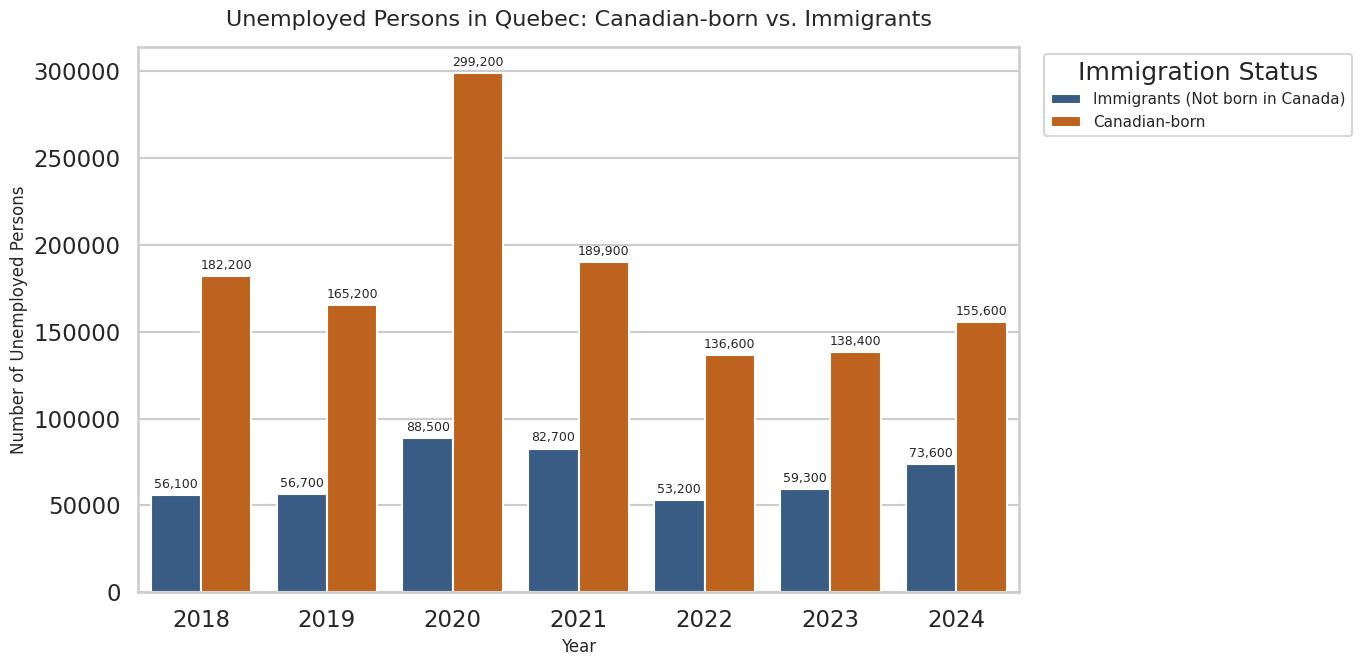

,Year,Status,Unemployed_Persons
23870,2018,Canadian-born,182200.0
23790,2018,Immigrants (Not born in Canada),56100.0
25790,2019,Canadian-born,165200.0
25710,2019,Immigrants (Not born in Canada),56700.0
27710,2020,Canadian-born,299200.0
27630,2020,Immigrants (Not born in Canada),88500.0
29630,2021,Canadian-born,189900.0
29550,2021,Immigrants (Not born in Canada),82700.0
31550,2022,Canadian-born,136600.0
31470,2022,Immigrants (Not born in Canada),53200.0


In [31]:


# 1. Download official Unemployment table (Table 14-10-0083-01)
url_lfs = "https://www150.statcan.gc.ca/n1/tbl/csv/14100083-eng.zip"
print("Downloading official unemployment data by immigration status...")

r = requests.get(url_lfs)
with zipfile.ZipFile(io.BytesIO(r.content)) as z:
    df_lfs = pd.read_csv(z.open("14100083.csv"), low_memory=False)

print("Download completed!")

# 2. Exact official categories from table 14-10-0083-01
status_categories = [
    "Born in Canada",
    "Landed immigrants",
    "Non-permanent residents",
]

# Filter for Quebec and TOTAL NUMBER of unemployed persons
df_unemployed = df_lfs[
    (df_lfs["GEO"] == "Quebec")
    & (df_lfs["Labour force characteristics"] == "Unemployment")
    & (df_lfs["Age group"] == "15 years and over")
    & (df_lfs["Immigrant status"].isin(status_categories))
].copy()

# 3. Clean and calculate number of persons (StatCan reports in thousands, multiply by 1,000)
df_unemployed["Year"] = df_unemployed["REF_DATE"].astype(int)
df_unemployed = df_unemployed[df_unemployed["Year"] >= 2018].dropna(
    subset=["VALUE"]
)
df_unemployed["Unemployed_Persons"] = (
    df_unemployed["VALUE"] * 1000
).round()

# Map clear English names
translations = {
    "Born in Canada": "Canadian-born",
    "Landed immigrants": "Immigrants (Not born in Canada)",
    "Non-permanent residents": "Non-permanent residents",
}
df_unemployed["Status"] = df_unemployed["Immigrant status"].map(translations)

# 4. Generate comparative chart with the 3 categories
plt.figure(figsize=(14, 7))
ax = sns.barplot(
    data=df_unemployed,
    x="Year",
    y="Unemployed_Persons",
    hue="Status",
    palette=["#2b5c8f", "#d95f02"],
)

plt.title(
    "Unemployed Persons in Quebec: Canadian-born vs. Immigrants",
    fontsize=16,
    pad=15,
)
plt.ylabel("Number of Unemployed Persons", fontsize=12)
plt.xlabel("Year", fontsize=12)
plt.legend(
    title="Immigration Status",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=11,
)

# Numeric labels formatted with thousands separator
for container in ax.containers:
    ax.bar_label(
        container,
        fmt=lambda x: f"{int(x):,}" if x > 0 else "",
        padding=3,
        size=9,
    )

plt.tight_layout()
plt.show()

# 5. Display the complete table sorted by year and status
display(
    df_unemployed[
        ["Year", "Status", "Unemployed_Persons"]
    ].sort_values(by=["Year", "Status"])
)


In [32]:


# 1. Get percentage distribution of unemployed
df_dist = df_unemployed.groupby(['Year', 'Status'])['Unemployed_Persons'].sum().unstack()
df_prop = df_dist.div(df_dist.sum(axis=1), axis=0)

# 2. Cross-reference with the actual total of Quebec EI beneficiaries
df_ei_annual['Year'] = df_ei_annual['Year'].astype(int)
df_merged = pd.merge(df_prop, df_ei_annual.set_index('Year'), on='Year')

# 3. Calculate estimated beneficiaries per group
df_merged['Beneficiaries: Canadian-born'] = (df_merged['Canadian-born'] * df_merged['Avg_Monthly_Beneficiaries']).round()
df_merged['Beneficiaries: Immigrants'] = (df_merged['Immigrants (Not born in Canada)'] * df_merged['Avg_Monthly_Beneficiaries']).round()

# 4. Format final table
df_final = df_merged[['Avg_Monthly_Beneficiaries', 'Beneficiaries: Canadian-born', 'Beneficiaries: Immigrants']].reset_index()
df_final.columns = ['Year', 'Total EI Beneficiaries (Quebec)', 'Canadian-born (Estimated)', 'Immigrants (Estimated)']

display(df_final)

,Year,Total EI Beneficiaries (Quebec),Canadian-born (Estimated),Immigrants (Estimated)
0,2018,31704.0,24240.0,7464.0
1,2019,30554.0,22747.0,7807.0
2,2020,43078.0,33245.0,9833.0
3,2021,82050.0,57158.0,24892.0
4,2022,33907.0,24403.0,9504.0
5,2023,27679.0,19377.0,8302.0
6,2024,30475.0,20689.0,9786.0


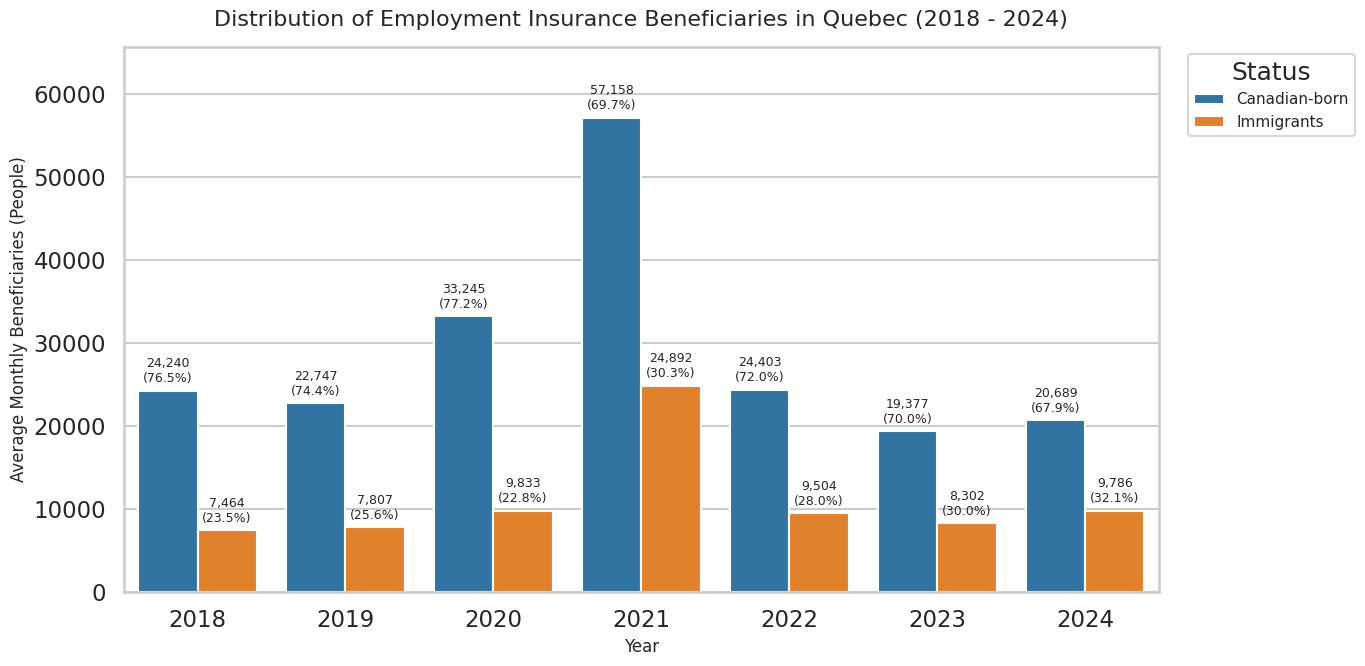

In [33]:


# 1. Transform df_final to long format (tidy) for Seaborn
df_plot = df_final.melt(
    id_vars=['Year', 'Total EI Beneficiaries (Quebec)'],
    value_vars=['Canadian-born (Estimated)', 'Immigrants (Estimated)'],
    var_name='Status',
    value_name='Beneficiaries',
)

# Translate legend names to shorter English versions
legend_translations = {
    'Canadian-born (Estimated)': 'Canadian-born',
    'Immigrants (Estimated)': 'Immigrants'
}
df_plot['Status'] = df_plot['Status'].map(legend_translations)

# 2. Calculate the percentage proportion for each group
df_plot['Percentage'] = (
    df_plot['Beneficiaries'] / df_plot['Total EI Beneficiaries (Quebec)']
) * 100

# 3. Create the grouped bar chart
plt.figure(figsize=(14, 7))
ax = sns.barplot(
    data=df_plot,
    x='Year',
    y='Beneficiaries',
    hue='Status',
    palette=['#1f77b4', '#ff7f0e'],
)

# 4. Chart customization
plt.title(
    'Distribution of Employment Insurance Beneficiaries in Quebec (2018 - 2024)',
    fontsize=16,
    pad=15,
)
plt.ylabel('Average Monthly Beneficiaries (People)', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.legend(
    title='Status', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=11
)

# 5. Add labels with the number and percentage share on top of each bar
for i, container in enumerate(ax.containers):
    # Get the corresponding percentages for each series
    subset_pct = df_plot[
        df_plot['Status'] == ('Canadian-born' if i == 0 else 'Immigrants')
    ]['Percentage'].values

    for bar, pct in zip(container, subset_pct):
        h = bar.get_height()
        if h > 0:
            ax.annotate(
                f'{int(h):,}\n({pct:.1f}%)',
                xy=(bar.get_x() + bar.get_width() / 2, h),
                xytext=(0, 4),
                textcoords='offset points',
                ha='center',
                va='bottom',
                fontsize=9,
            )

plt.ylim(0, df_plot['Beneficiaries'].max() * 1.15)
plt.tight_layout()
plt.show()

## Statistical Analysis: Immigration and the Employment Insurance System in Quebec




**Introduction and Clarification of Concepts**

In Quebec's public discourse, there is a recurring narrative that associates the increase in the use of unemployment insurance (*chômage* or *Assurance-emploi*) with the arrival of recent immigrants and asylum seekers. To evaluate the veracity of this claim, it is imperative to make a technical and legal distinction: the (federal) Employment Insurance requires the prior accumulation of hours worked and contributed in Canada.

By legal definition, a newly arrived asylum seeker does not have access to this system, as they have not participated in the formal labor market. Any economic impact from this demographic group falls on the provincial Social Assistance (*Bien-être social*), not on *chômage*.

Having clarified this point, this analysis examines the actual behavior of unemployment and the use of Employment Insurance according to immigration status, using official data from Statistics Canada (Tables 14-10-0083-01 and 14-10-0009-01).

**1. Unemployment Dynamics: Initial Gap and Long-Term Convergence**

When analyzing the unemployment rate in Quebec segmented by immigration status during the 2021-2023 period, the data reveals a clear statistical pattern of labor integration:

*   **Integration Phase (Immigrants with 5 years or less):** This group consistently presents the highest unemployment rates (13.1% in 2021; 7.9% in 2022; 9.4% in 2023). This is an expected structural phenomenon, a result of temporary language barriers, a lack of networking contacts, and the time required for foreign credential recognition.
*   **Structural Convergence (Immigrants with more than 10 years):** As immigrants settle, their employability improves drastically. By 2023, the unemployment rate for established immigrants dropped to 5.5%, significantly approaching the 3.8% of the Canadian-born population.

*Partial Conclusion:* Immigrants do face higher unemployment upon arrival, but it is a temporary effect. After surpassing a decade of residency, their absorption into the Quebec labor market is highly successful, debunking the idea of chronic unemployment sustained by immigration.

**2. Trends in Assurance-Emploi Beneficiaries**


The visualization of the average monthly number of regular benefit recipients in Quebec (2018-2026) demonstrates that the volume of unemployment insurance users responds to macroeconomic cycles, not migratory flows.

*   **The Systemic Factor:** The historical peak is observed between 2020 (43,078 beneficiaries) and 2021 (82,050 beneficiaries). This statistical anomaly is attributable to the COVID-19 pandemic and economic shutdowns, affecting the entire workforce regardless of origin.
*   **Market Normalization:** For the years 2022 and 2023, the numbers collapsed to 33,907 and 27,679 respectively, returning to pre-pandemic levels (similar to the 31,704 in 2018), even though in these same years Canada and Quebec experienced record admissions of new temporary and permanent residents.

**Methodological Note: The Illusion of Proportions (Relative Rates vs. Absolute Volumes)**

When interpreting employment visualizations, it is crucial not to confuse the unemployment rate (a percentage) with the total volume of unemployed individuals (an absolute number). In labor statistics, the metric is calculated using the following formula:

*Unemployment Rate = (Unemployed Persons / Total Labor Force) × 100*

This formula shows that the percentage is highly sensitive to the size of the denominator (the Labor Force).

*   **Canadian-Born Population:** Represents the vast majority of the province's labor force. Having a massive denominator in the equation means a low percentage (such as 3.8% in 2023) translates into a very large absolute volume of unemployed individuals.
*   **Recent Immigrants (≤ 5 years):** Represent a much smaller fraction of the total labor force. Having a small denominator means any variation in the number of unemployed individuals generates a dramatic jump in the percentage (such as 9.4% in 2023).

Illustrative Example:*
If the Canadian-born labor force were 3,000,000 people, a rate of 3.8% would equal 114,000 unemployed individuals. In contrast, if the recent immigrant labor force were 200,000 people, a rate of 9.4% would equal 18,800 unemployed individuals.

Therefore, although the graph shows the rate for recent immigrants is more than twice as high, the actual number of unemployed Canadian-born individuals is significantly larger. Visually, the bar for recent immigrants is taller, but the absolute impact on the labor market and the demand for government services comes mostly from the majority population.

**General Conclusion**

The empirical analysis refutes the narrative that immigrants or asylum seekers are "draining" the Assurance-emploi system in Quebec.
*   Asylum seekers are not included in these statistics due to the system's own restrictions.
*   Peaks in unemployment insurance usage respond to systemic economic crises (like the pandemic), not to the volume of immigration.
*   Unemployment within the immigrant population is a temporary acclimation factor that corrects almost entirely over the years.
*   Those who use *chômage* are workers (immigrants or Canadian-born) who have already contributed to the system through payroll premiums, exercising an acquired labor right.

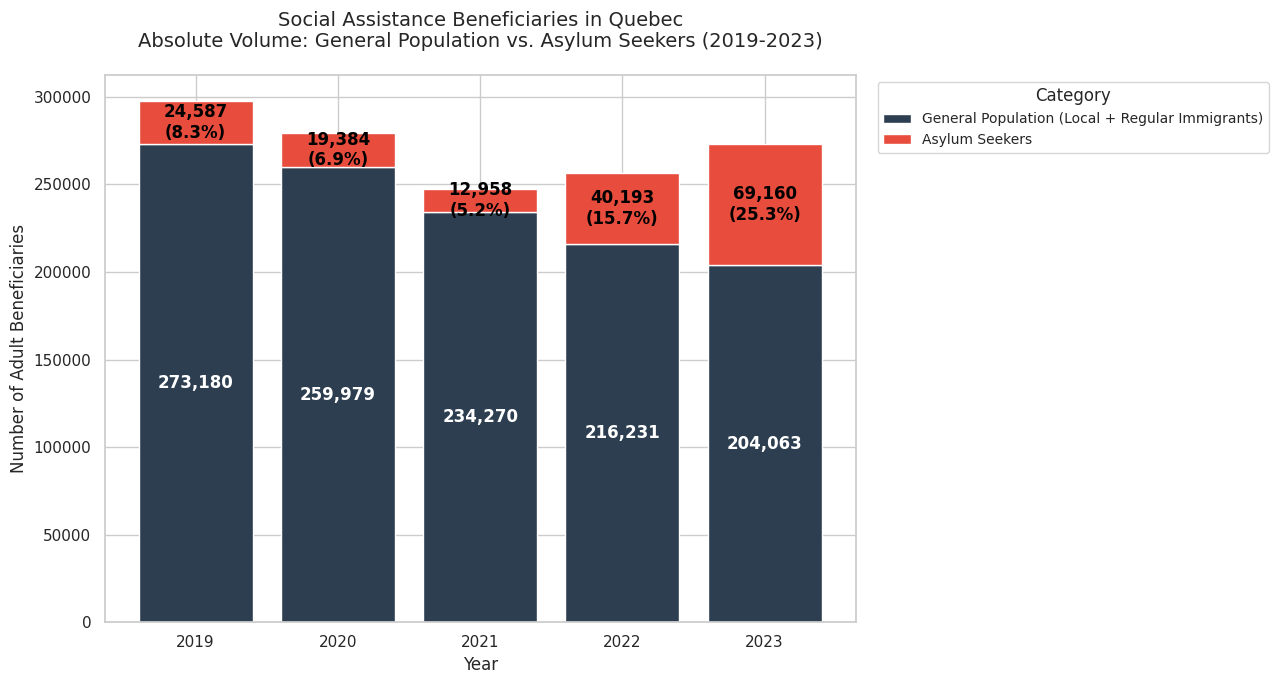

Structured Data Table:


,Year,General_Population,Asylum_Seekers,Total_Beneficiaries
0,2019,273180,24587,297767
1,2020,259979,19384,279363
2,2021,234270,12958,247228
3,2022,216231,40193,256424
4,2023,204063,69160,273223


In [34]:


# 1. Create DataFrame with official MESS data (2019-2023)
# Source: MESS Access to Information document (August 12, 2024)
data = {
    'Year': [2019, 2020, 2021, 2022, 2023],
    'Total_Beneficiaries': [
        297767,
        279363,
        247228,
        256424,
        273223,
    ], # Annualized monthly average
    'Asylum_Seekers': [
        24587,
        19384,
        12958,
        40193,
        69160,
    ], # Distinct adults
}
df_mess = pd.DataFrame(data)

# 2. Calculate general population (locals + other immigrants) and percentages
df_mess['General_Population'] = df_mess['Total_Beneficiaries'] - df_mess['Asylum_Seekers']
df_mess['Asylum_Pct'] = (df_mess['Asylum_Seekers'] / df_mess['Total_Beneficiaries']) * 100

# 3. Chart aesthetic setup
plt.figure(figsize=(13, 7))
sns.set_theme(style='whitegrid')

# 4. Create stacked bar chart
bars_general = plt.bar(
    df_mess['Year'],
    df_mess['General_Population'],
    color='#2c3e50',
    label='General Population (Local + Regular Immigrants)',
)
bars_asylum = plt.bar(
    df_mess['Year'],
    df_mess['Asylum_Seekers'],
    bottom=df_mess['General_Population'],
    color='#e74c3c',
    label='Asylum Seekers',
)

# 5. Labels and formatting
plt.title(
    'Social Assistance Beneficiaries in Quebec\n'
    'Absolute Volume: General Population vs. Asylum Seekers (2019-2023)',
    fontsize=14,
    pad=20,
)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Adult Beneficiaries', fontsize=12)
plt.xticks(df_mess['Year'])

plt.legend(
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    frameon=True,
    title='Category',
    fontsize=10,
)

# 6. Add numerical values inside bars
for bar1, bar2, pct in zip(bars_general, bars_asylum, df_mess['Asylum_Pct']):
    # General Population label
    plt.text(
        bar1.get_x() + bar1.get_width() / 2,
        bar1.get_height() / 2,
        f'{int(bar1.get_height()):,}',
        ha='center',
        va='center',
        color='white',
        fontweight='bold',
    )

    # Asylum Seekers label
    plt.text(
        bar2.get_x() + bar2.get_width() / 2,
        bar1.get_height() + bar2.get_height() / 2,
        f'{int(bar2.get_height()):,}\n({pct:.1f}%)',
        ha='center',
        va='center',
        color='black',
        fontweight='bold',
    )

plt.tight_layout()
plt.show()

# Print DataFrame output
print('Structured Data Table:')
display(
    df_mess[['Year', 'General_Population', 'Asylum_Seekers', 'Total_Beneficiaries']]
)

## Data Sources (Data Provenance)
The structured data in this DataFrame was extracted from:
1. **General Population Social Assistance:** Consolidated averages from the *Rapport statistique sur la clientèle des programmes d'assistance sociale* (MESS, 2019-2023).
2. **Volume of Asylum Seekers:** Access to Information document issued by the *Direction de l'intelligence d'affaires et de l'analytique* of the MESS (August 12, 2024).
3. **Local Decline Trend:** Internal MESS document (March 2024) confirming a 1.6% year-over-year decrease in regular clientele, mathematically offset by the exogenous influx of asylum seekers (who represented 18% of the system in Q1 2024).

## Objective Statistical Analysis and Conclusion

**A. The paradox of rates vs. the base volume:**

Empirical data debunks the narrative that asylum seekers "are the ones who use" the system the most in absolute terms. In 2023, the local population and regular immigration made up approximately 74.6% of the system's total weight (204,063 individuals), compared to 25.3% for asylum seekers. The public narrative stems from relative acceleration: asylum seekers on social assistance grew by an alarming 433% between 2021 (12,958) and 2023 (69,160), creating visible budgetary tension, but they still represent a minority of the general registry. By March 2024, they only represented 18% of the total.

**B. Statistical "Masking" Effect:**

Interestingly, statistics reveal that the Quebec general population's reliance on *Bien-être social* has been in structural decline (dropping from over 273,000 individuals in 2019 to just over 204,000 in 2023). The ministry's own documents indicate that the overall decrease in social assistance would have continued and been much more apparent if not for the massive influx of asylum seekers. In other words, the program's crisis does not stem from increased usage by the majority population, but from a localized exogenous demographic shock.

**C. Structural Redirection (Aide de dernier recours):**

By cross-referencing the conclusion of your first phase (*Assurance-emploi*) with this analysis, an institutional domino effect becomes evident. Since *demandeurs d'asile* (asylum seekers) do not have legal access to federal funds (due to a lack of withholding history), the legal architecture pushes them toward provincial assistance, precisely labeled as the "last resort program". Their presence here is not a statistical anomaly, but the only mathematical and institutional way out while they wait for their work permits to be regularized.